In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pathlib import Path
import cv2
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'good_dir': r'D:\_Dataset\M6_29Sep2023\Good',
    'bad_dir': r'D:\_Dataset\M6_29Sep2023\Bad',
    'img_size': (500, 500),
    'batch_size': 8,
    'epochs': 50,
    'learning_rate': 0.0000,
    'model_save_path': 'models/cnn_augmented_500px.pth',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

device = torch.device(CONFIG['device'])
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ============================================================================
# CNN ARCHITECTURE
# ============================================================================

class QualityNet(nn.Module):
    def __init__(self):
        super(QualityNet, self).__init__()
        
        # 500x500 input
        self.features = nn.Sequential(
            self._conv_block(3, 32),   # 250x250
            self._conv_block(32, 64),  # 125x125
            self._conv_block(64, 128), # 62x62
            self._conv_block(128, 256),# 31x31
            self._conv_block(256, 512),# 15x15
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
# ============================================================================
# DATASET
# ============================================================================

class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, img_size, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================

def get_data():
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    def get_files(directory, label):
        p = [str(f) for f in Path(directory).glob('*') if f.suffix.lower() in valid_ext]
        return p, [label] * len(p)

    g_paths, g_labels = get_files(CONFIG['good_dir'], 1)
    b_paths, b_labels = get_files(CONFIG['bad_dir'], 0)
    
    return train_test_split(g_paths + b_paths, g_labels + b_labels, test_size=0.2, random_state=42)

def main():
    train_p, val_p, train_l, val_l = get_data()
    
    # ImageNet normalization helps convergence
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_ds = ImageDataset(train_p, train_l, CONFIG['img_size'], transform)
    val_ds = ImageDataset(val_p, val_l, CONFIG['img_size'], transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'])

    model = QualityNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    criterion = nn.BCELoss()
    
    print(f"Training on {len(train_ds)} images at {CONFIG['img_size']} resolution...")

    best_val_acc = 0

    for epoch in range(CONFIG['epochs']):
        model.train()
        train_loss = 0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                out = model(imgs.to(device))
                all_preds.extend((out > 0.5).float().cpu().numpy())
                all_labels.extend(lbls.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        avg_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}")
        
        # Save best model
        if acc > best_val_acc:
            best_val_acc = acc
            torch.save(model.state_dict(), CONFIG['model_save_path'])
            print(f"  --> New best accuracy! Model saved.")

    print("\nTraining Complete.")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Starting training on cuda...


Epoch 1: 100%|██████████| 60/60 [00:05<00:00, 11.17it/s]


Loss: 0.6837 | Val Loss: 0.6936 | Val Acc: 0.4833
  --> Model Saved


Epoch 2: 100%|██████████| 60/60 [00:05<00:00, 11.67it/s]


Loss: 0.6448 | Val Loss: 0.7605 | Val Acc: 0.4833


...

Loss: 0.0826 | Val Loss: 0.4039 | Val Acc: 0.7833


Epoch 49: 100%|██████████| 60/60 [00:05<00:00, 11.37it/s]


Loss: 0.0574 | Val Loss: 0.0198 | Val Acc: 1.0000


Epoch 50: 100%|██████████| 60/60 [00:05<00:00, 11.34it/s]


Loss: 0.0845 | Val Loss: 0.0475 | Val Acc: 0.9917

Graph saved as 'training_log.png'


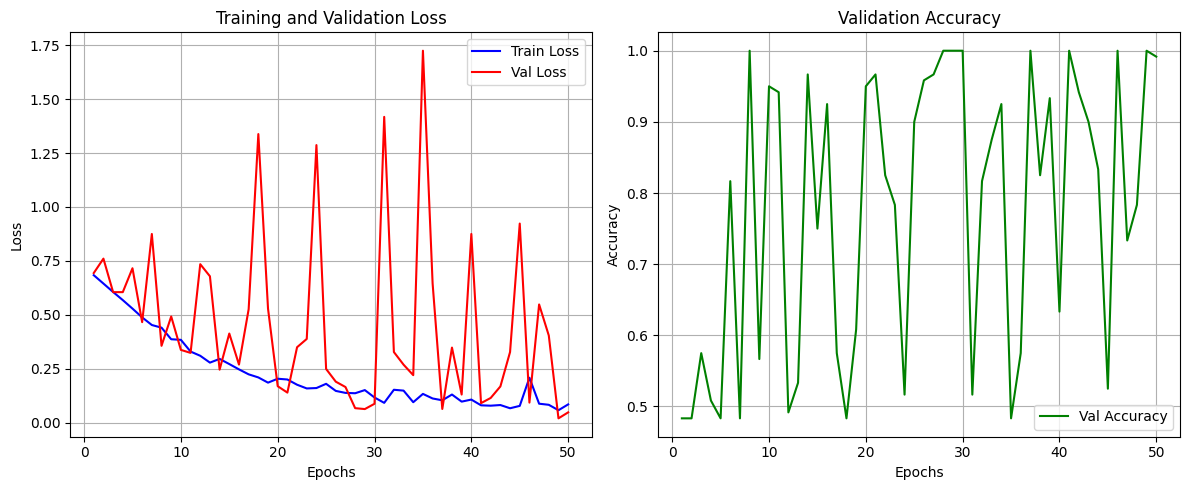

In [10]:
if __name__ == '__main__':
    main()